# 🚀 07 — Unified Model Training (Google Colab)

**TFM UNIR — Detección de Objetos para ESP32-S3**

Notebook unificado para entrenar **4 familias de modelos** en Google Colab con GPU T4:

| Familia | Variantes | Framework |
|---------|-----------|-----------|
| YOLO11 | n / s / m / l / x | Ultralytics |
| YOLO26 | n / s / m / l / x | Ultralytics |
| MobileNetV2 + SSD-Lite | alpha 0.35/0.5/1.0 | TensorFlow/Keras |
| MobileNetV3 + SSD-Lite | Small / Large | TensorFlow/Keras |

### Pipeline (12 Bloques)
1. **Setup** — Instalar dependencias, montar Drive, detectar GPU
2. **Selección** — Elegir familia/variante/hiperparámetros con widgets
3. **Verificación Dataset** — Validar estructura y distribución de clases
4. **Construcción Modelo** — Cargar/construir el modelo seleccionado
5. **Entrenamiento** — YOLO (1 fase) o MobileNet (2 fases)
6. **Curvas de Entrenamiento** — Visualización estandarizada
7. **Validación** — Evaluación en split **val**
8. **Inferencia Visual** — Predicciones sobre muestras
9. **Evaluación Test** — Métricas finales en split **test**
10. **Export TFLite INT8** — Cuantización para ESP32-S3 (< 8 MB)
11. **Comparación Framework vs TFLite** — Agreement, IoU, side-by-side
12. **Registro y Comparación** — Guardar experimento y comparar con anteriores

---
## Bloque 1 — Setup: Instalación, Drive, GPU

In [1]:
# ============================================================
# Bloque 1 — Setup  (Colab + Local compatible)
# ============================================================

import sys, os
from pathlib import Path

# 1.1  Detectar entorno
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    # --- Google Colab ---
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/TFM_UNIR/02_ING_MODELOS")
    # Instalar dependencias que no vienen en Colab por defecto
    get_ipython().system("pip install -q ultralytics ipywidgets pyyaml")
else:
    # --- Local (macOS / Linux) ---
    # Navegar desde el notebook hasta 02_ING_MODELOS
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "Google_Colab":
        PROJECT_ROOT = PROJECT_ROOT.parent          # → 02_ING_MODELOS
    elif PROJECT_ROOT.name != "02_ING_MODELOS":
        # Fallback: buscar 02_ING_MODELOS subiendo
        for p in PROJECT_ROOT.parents:
            if p.name == "02_ING_MODELOS":
                PROJECT_ROOT = p
                break

# 1.2  Añadir Google_Colab/ al sys.path para importar src_colab
COLAB_DIR = PROJECT_ROOT / "Google_Colab"
if str(COLAB_DIR) not in sys.path:
    sys.path.insert(0, str(COLAB_DIR))

# 1.3  Setup unificado (GPU, paths, seed)
from src_colab import setup_environment

env, paths = setup_environment(project_root=PROJECT_ROOT)


🖥️  Entorno: Local
🎮 GPU: Apple MPS
   CUDA: ❌  |  MPS: ✅  |  TF-GPU: ✅

📂 Project root: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS
📁 Datasets:     /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets
📁 Models:        /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models
📁 Logs:          /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs
📁 Reports:       /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports
📁 Experiments:   /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments


---
## Bloque 2 — Selección de Modelo e Hiperparámetros

Usa los **widgets interactivos** para elegir la familia, variante,
dataset, y parámetros de entrenamiento.  
Si los widgets no funcionan, usa `create_manual_setup()` más abajo.

In [2]:
# ============================================================
# Bloque 2 — Selección con Widgets
# ============================================================

from src_colab import create_model_selector, create_manual_setup

# Mostrar panel interactivo (retorna un ExperimentSetup que se rellena
# al pulsar "Aplicar Configuración" dentro del widget)
setup = create_model_selector()

In [3]:
# 2.2  Confirmar selección (ejecutar tras pulsar "Aplicar Configuración")
print(setup)

# -- Si los widgets no funcionan, descomenta y personaliza:
# setup = create_manual_setup(
#     model_family="YOLO26",
#     model_variant="yolo26n",
#     version="v0_test",
#     dataset_name="yolo26",
#     class_names=['dog', 'door', 'obstacle', 'person', 'stair'],
#     img_size=224,
#     batch_size=16,       # ← reducido de 32 a 16
#     epochs=1,
#     patience=1,
# )
#
# # Después de crear el setup, forzar parámetros conservadores:
# setup.yolo_config["mixup"] = 0.0      # ← desactivar mixup
# setup.yolo_config["mosaic"] = 0.0     # ← desactivar mosaic  
# setup.yolo_config["copy_paste"] = 0.0

ExperimentSetup(model_family='MobileNetV3', model_variant='MobileNetV3S_SSDLite', version='v0', description='Pruebas', dataset_name='tfrecord', class_names=['dog', 'door', 'obstacle', 'person', 'stair'], num_classes=5, img_size=224, batch_size=12, patience=1, seed=42, conf_threshold=0.26, iou_threshold=0.44999999999999996, yolo_config={}, mobilenet_config={'phase1_epochs': 2, 'phase1_lr': 0.001, 'phase2_epochs': 2, 'phase2_lr': 5.011872336272725e-05, 'phase2_unfreeze_layers': 40, 'augmentation_level': 'none', 'backbone_alpha': 0.75, 'minimalistic': True, 'dropout_rate': 0.25, 'l2_reg': 3.1622776601683795e-05, 'feature_channels': 192, 'num_anchors_per_cell': 9, 'focal_alpha': 0.25, 'focal_gamma': 1.9999999999999998, 'neg_pos_ratio': 3, 'use_copy_paste': False, 'use_class_weights': True, 'class_weight_method': 'sqrt_inverse'}, experiment_name='MBNTv3S_ssdlite_v0')


---
## Bloque 3 — Verificación del Dataset

Valida la estructura del dataset y muestra la distribución de clases.
- **YOLO**: espera `train/images`, `train/labels`, etc.
- **MobileNet**: espera TFRecords (`train.tfrecord`, `val.tfrecord`, `metadata.json`)

📂 Dataset original: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord


2026-02-07 17:02:03.850693: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-07 17:02:03.850925: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-07 17:02:03.850932: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1770501723.851386  121945 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770501723.851780  121945 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-07 17:02:03.946711: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-07 17:02:04.238159: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with 


📂 Dataset TFRecord: tfrecord
   Clases: ['dog', 'door', 'obstacle', 'person', 'stair']
  ✅ train:  9722 ejemplos
  ✅   val:  2066 ejemplos
  ✅  test:  2066 ejemplos


2026-02-07 17:02:08.407662: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


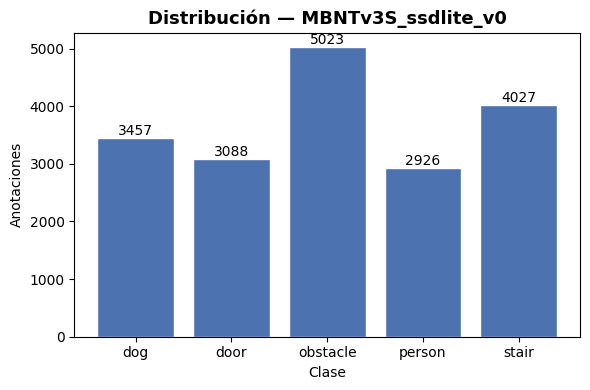


📊 Class weights (inverse_freq):
   dog:  3457 samples → weight=1.453
   door:  3088 samples → weight=1.627
   obstacle:  5023 samples → weight=1.000
   person:  2926 samples → weight=1.717
   stair:  4027 samples → weight=1.247

⚖️  Class weights: [1.4529939 1.6266192 1.        1.716678  1.2473305]


In [4]:
# ============================================================
# Bloque 3 — Verificación del Dataset
# ============================================================

import os
from pathlib import Path
from src_colab import (
    verify_dataset, get_class_distribution, plot_class_distribution,
    calculate_class_weights, generate_data_yaml, delete_yolo_cache,
    create_yolo_working_copy, DATASET_MASTER_CLASSES,
    is_yolo_family, is_mobilenet_family,
    visualize_gt_samples_per_class,
)

family = setup.model_family

# Construir dataset_path a partir de paths.datasets_dir + dataset_name
dataset_path = os.path.join(paths.datasets_dir, setup.dataset_name)
print(f"📂 Dataset original: {dataset_path}")

# 3.0  Descomprimir si solo existe el .zip
dataset_zip = dataset_path + ".zip"

if not os.path.isdir(dataset_path) and os.path.isfile(dataset_zip):
    print(f"Ruta del Dataset.Zip: {dataset_zip}")
    import zipfile
    print(f"📦 Descomprimiendo {dataset_zip} ...")
    with zipfile.ZipFile(dataset_zip, 'r') as zf:
        zf.extractall(dataset_path)
    print(f"   ✅ Descomprimido en {dataset_path}")


# 3.1  Verificar estructura del dataset original
verification = verify_dataset(dataset_path, family)
if not verification.get("valid", False):
    print(f"⚠️  Problemas detectados: {verification.get('issues', [])}")
    raise RuntimeError(f"❌ Dataset no válido en: {dataset_path}")

# 3.2  Working copy para subconjuntos de clases (solo YOLO)
if is_yolo_family(family):
    master = DATASET_MASTER_CLASSES.get(setup.dataset_name)
    if master and (setup.class_names != master):
        print(f"\n⚠️  Subconjunto o reorden de clases detectado:")
        print(f"   Master ({len(master)})    : {master}")
        print(f"   Seleccionadas ({len(setup.class_names)}): {setup.class_names}")
        dataset_path, data_yaml_path, filter_stats = create_yolo_working_copy(
            original_dir=dataset_path,
            master_classes=master,
            selected_classes=setup.class_names,
        )
    else:
        # Todas las clases en el mismo orden → dataset original
        if master is None:
            print(f"\n⚠️  Dataset '{setup.dataset_name}' no tiene master_classes "
                  f"definido en DATASET_MASTER_CLASSES. Se asume que los labels "
                  f"ya están alineados con: {setup.class_names}")
        data_yaml_path = generate_data_yaml(
            dataset_dir=dataset_path,
            class_names=setup.class_names,
        )
        delete_yolo_cache(dataset_path)

    print(f"\n📂 Dataset de trabajo: {dataset_path}")
    print(f"📄 data.yaml: {data_yaml_path}")

# 3.3  Distribución de clases (sobre el working copy o el original)
dist = get_class_distribution(dataset_path, family, setup.class_names)
plot_class_distribution(dist, title=f"Distribución — {setup.experiment_name}")

# 3.4  Pesos de clase (para desbalance)
class_weights = calculate_class_weights(dist, method="inverse_freq")
print(f"\n⚖️  Class weights: {class_weights}")

# 3.5  Muestras GT aleatorias por clase (solo YOLO)
if is_yolo_family(family):
    visualize_gt_samples_per_class(
        dataset_dir=dataset_path,
        class_names=setup.class_names,
        split="train",
        samples_per_class=3,
        title=f"GT Samples (train) — {setup.experiment_name}",
    )

---
## Bloque 4 — Construcción del Modelo

- **YOLO**: carga el `.pt` preentrenado
- **MobileNet**: construye backbone + SSD-Lite head con anclas personalizables

In [6]:

# ============================================================
# Bloque 4 — Construcción del Modelo
# ============================================================

from src_colab import (
    load_yolo_model, build_mobilenet_ssd,
    print_model_summary, estimate_model_size, estimate_esp32_inference,
    generate_anchors, compute_anchor_statistics,
    create_mobilenet_pipeline,
)

if is_yolo_family(family):
    # ── YOLO ──
    model = load_yolo_model(family, setup.model_variant)
    print_model_summary(model, family)
    estimate_model_size(model, family)
    esp32_est = estimate_esp32_inference(family, setup.model_variant)
    if esp32_est:
        print(f"⏱️  ESP32-S3 estimado: {esp32_est['estimated_esp32_ms']:.0f} ms "
              f"({esp32_est['estimated_esp32_fps']:.1f} FPS)")

else:
    # ── MobileNet + SSD-Lite ──
    mc = setup.mobilenet_config

    # 4.1  Generar anclas
    anchor_sizes = mc.get("anchor_sizes", [0.1, 0.2, 0.37, 0.54, 0.71, 0.88])
    anchor_ratios = mc.get("anchor_ratios", [1.0, 2.0, 0.5, 3.0, 0.33])
    anchors = generate_anchors(
        imgsz=setup.img_size,
        sizes=anchor_sizes,
        ratios=anchor_ratios,
    )
    compute_anchor_statistics(anchors)
    print(f"📦 Anclas generadas: {anchors.shape}")

    # 4.2  Crear pipelines TFRecord
    train_ds = create_mobilenet_pipeline(
        dataset_path, "train", anchors, setup.class_names,
        batch_size=setup.batch_size, imgsz=setup.img_size,
        augment_level=mc.get("augmentation_level", "medium"),
    )
    val_ds = create_mobilenet_pipeline(
        dataset_path, "val", anchors, setup.class_names,
        batch_size=setup.batch_size, imgsz=setup.img_size,
        augment_level="none",
    )
    print(f"📊 Pipeline: train={train_ds}, val={val_ds}")

    # 4.3  Construir modelo
    # num_anchors_per_cell = scales × aspect_ratios (no el total de anclas)
    num_anchors_per_cell = len(anchor_sizes) * len(anchor_ratios)
    version = "v2" if "v2" in family.lower() else "v3"

    # Extraer variante (Small/Large) del nombre completo del model_variant
    # Ej: "MobileNetV3S_SSDLite" → "Small", "MobileNetV3L_SSDLite" → "Large"
    #     "MobileNetV2_SSDLite"  → "Small" (no se usa en V2, pero queda coherente)
    mv = (setup.model_variant or "").lower()
    if "v3l" in mv or "large" in mv:
        variant = "Large"
    elif "v3s" in mv or "small" in mv:
        variant = "Small"
    else:
        variant = "Small"  # default seguro para V2 y V3

    model = build_mobilenet_ssd(
        version=version.upper(),
        variant=variant,
        num_classes=len(setup.class_names),
        num_anchors_per_cell=num_anchors_per_cell,
        img_size=setup.img_size,
    )
    print_model_summary(model, family)
    estimate_model_size(model, family)
    esp32_est = estimate_esp32_inference(family, variant)
    if esp32_est:
        print(f"⏱️  ESP32-S3 estimado: {esp32_est['estimated_esp32_ms']:.0f} ms "
              f"({esp32_est['estimated_esp32_fps']:.1f} FPS)")


⚓ Anchors: 1470  |  W: [0.057, 1.524]  |  H: [0.058, 1.532]
📦 Anclas generadas: (1470, 4)
📂 Pipeline train: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord/train.tfrecord
📂 Pipeline val: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord/val.tfrecord
📊 Pipeline: train=<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'objectness': TensorSpec(shape=(None, 1470, 1), dtype=tf.float32, name=None), 'class_out': TensorSpec(shape=(None, 1470, 5), dtype=tf.float32, name=None), 'bbox_out': TensorSpec(shape=(None, 1470, 4), dtype=tf.float32, name=None)})>, val=<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'objectness': TensorSpec(shape=(None, 1470, 1), dtype=tf.float32, name=None), 'class_out': TensorSpec(shape=(None, 1470, 5), dtype=tf.float32, name=None), 'bbox_out': TensorSpec(shape=(None, 1470, 4), dtype=tf.float32, name=None)})>
✅ Modelo construido: Mobile

---
## Bloque 5 — Entrenamiento

- **YOLO**: fase única con Ultralytics `model.train()`
- **MobileNet**: **Phase 1** (backbone congelado) + **Phase 2** (descongelado parcial)

In [7]:
# ============================================================
# Bloque 5 — Entrenamiento
# ============================================================

import time
from src_colab import (
    YoloTrainConfig, train_yolo, validate_yolo,
    create_ssd_loss, create_callbacks,
    train_mobilenet_phase1, train_mobilenet_phase2,
    save_training_history, combine_histories,
    get_yolo_device, safe_mkdir,
)

# Directorio de salida para este experimento
exp_dir = os.path.join(paths.models_dir, setup.experiment_name)
safe_mkdir(exp_dir)

t_start = time.time()

if is_yolo_family(family):
    # ── YOLO Training ──
    yc = setup.yolo_config
    cfg = YoloTrainConfig(
        model=f"{setup.model_variant}.pt",
        imgsz=setup.img_size,
        epochs=yc.get("epochs", 100),
        patience=setup.patience,
        batch=setup.batch_size,
        optimizer=yc.get("optimizer", "auto"),
        lr0=yc.get("lr0", 0.01),
        lrf=yc.get("lrf", 0.01),
        mosaic=yc.get("mosaic", 1.0),
        mixup=yc.get("mixup", 0.0),
        device=get_yolo_device(env),
        project=exp_dir,
        name="train",
    )
    results = train_yolo(data_yaml_path, cfg)

else:
    # ── MobileNet Two-Phase Training ──
    mc = setup.mobilenet_config
    loss_dict = create_ssd_loss(
        num_classes=len(setup.class_names),
        class_weights=class_weights,
    )

    ckpt_dir = os.path.join(exp_dir, "checkpoints")
    log_dir = os.path.join(exp_dir, "logs")

    cbs_p1 = create_callbacks(
        ckpt_dir, log_dir,
        model_name=f"{setup.experiment_name}_p1",
        patience_reduce_lr=5, patience_early_stop=15,
    )

    p1_epochs = mc.get("phase1_epochs", 20)
    h1 = train_mobilenet_phase1(
        model, train_ds, val_ds,
        epochs=p1_epochs,
        lr=mc.get("phase1_lr", 1e-3),
        loss_dict=loss_dict,
        callbacks=cbs_p1,
    )
    p1_csv = os.path.join(log_dir, f"{setup.experiment_name}_p1_history.csv")
    save_training_history(h1, p1_csv, phase_label="phase1")

    cbs_p2 = create_callbacks(
        ckpt_dir, log_dir,
        model_name=f"{setup.experiment_name}_p2",
        patience_reduce_lr=8, patience_early_stop=20,
    )

    h2 = train_mobilenet_phase2(
        model, train_ds, val_ds,
        epochs=mc.get("phase2_epochs", 50),
        lr=mc.get("phase2_lr", 1e-4),
        unfreeze_layers=mc.get("phase2_unfreeze_layers", 20),
        loss_dict=loss_dict,
        callbacks=cbs_p2,
        initial_epoch=p1_epochs,
    )
    p2_csv = os.path.join(log_dir, f"{setup.experiment_name}_p2_history.csv")
    save_training_history(h2, p2_csv, phase_label="phase2")

    combined_csv = os.path.join(log_dir, f"{setup.experiment_name}_history.csv")
    combine_histories(p1_csv, p2_csv, combined_csv)

    # Guardar modelo final
    model.save(os.path.join(exp_dir, f"{setup.experiment_name}_final.keras"))

training_time_min = (time.time() - t_start) / 60
print(f"\n⏱️  Entrenamiento total: {training_time_min:.1f} min")

📋 Callbacks creados (5): checkpoint, ReduceLR, EarlyStopping, CSV, TB
🔒 Backbone congelado: 103 layers
   Trainable: 137,068 / 579,988 (23.6%)

🚀 Phase 1: Warm-up (2 épocas, LR=0.001)
Epoch 1/2


2026-02-07 17:11:17.872260: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


    811/Unknown 58s 64ms/step - bbox_out_loss: 0.0613 - class_out_loss: 0.1953 - loss: 0.2929 - objectness_loss: 0.0363

2026-02-07 17:12:14.853552: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6022471938147041292
2026-02-07 17:12:14.854714: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9824775375055192522
2026-02-07 17:12:14.854722: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6008422136948343185
2026-02-07 17:12:14.854731: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9370728372614644753
2026-02-07 17:12:14.854735: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12853484364488459853
2026-02-07 17:12:14.854738: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 18233773750984573926
2026-02-07 17:12:14.854740: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv i


Epoch 1: val_loss improved from None to 0.12121, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/checkpoints/MBNTv3S_ssdlite_v0_p1_best.keras


...


Epoch 3: val_loss improved from None to 0.08159, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/checkpoints/MBNTv3S_ssdlite_v0_p2_best.keras


2026-02-07 17:15:01.195977: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_6]]


811/811 ━━━━━━━━━━━━━━━━━━━━ 96s 108ms/step - bbox_out_loss: 0.0302 - class_out_loss: 0.0970 - loss: 0.1432 - objectness_loss: 0.0157 - val_bbox_out_loss: 0.0264 - val_class_out_loss: 0.0408 - val_loss: 0.0816 - val_objectness_loss: 0.0145 - learning_rate: 5.0119e-05
Epoch 4/4
811/811 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - bbox_out_loss: 0.0283 - class_out_loss: 0.0666 - loss: 0.1092 - objectness_loss: 0.0142

2026-02-07 17:16:22.170501: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1953865395871514696
2026-02-07 17:16:22.170573: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1288579998735302926
2026-02-07 17:16:22.170615: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 999451868957976370
2026-02-07 17:16:22.170617: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10930125711688238196
2026-02-07 17:16:22.170625: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10553894256612444694
2026-02-07 17:16:22.170631: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16858062457580343030
2026-02-07 17:16:22.170636: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv i


Epoch 4: val_loss improved from 0.08159 to 0.07812, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/checkpoints/MBNTv3S_ssdlite_v0_p2_best.keras
811/811 ━━━━━━━━━━━━━━━━━━━━ 86s 105ms/step - bbox_out_loss: 0.0286 - class_out_loss: 0.0669 - loss: 0.1111 - objectness_loss: 0.0153 - val_bbox_out_loss: 0.0258 - val_class_out_loss: 0.0376 - val_loss: 0.0781 - val_objectness_loss: 0.0143 - learning_rate: 5.0119e-05
Restoring model weights from the end of the best epoch: 4.
✅ Phase 2 completada en 3.0 min
💾 Historial guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/logs/MBNTv3S_ssdlite_v0_p2_history.csv
💾 Historial combinado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/logs/MBNTv3S_ssdlite_v0_history.csv

⏱️  Entrenamiento total: 5.2 min


---
## Bloque 6 — Curvas de Entrenamiento

Visualización estandarizada en 6 paneles:
`Total Loss` · `Box Loss` · `Cls Loss` · `Obj/DFL Loss` · `LR` · `Métricas`

📊 Curvas guardadas: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/training_curves.png


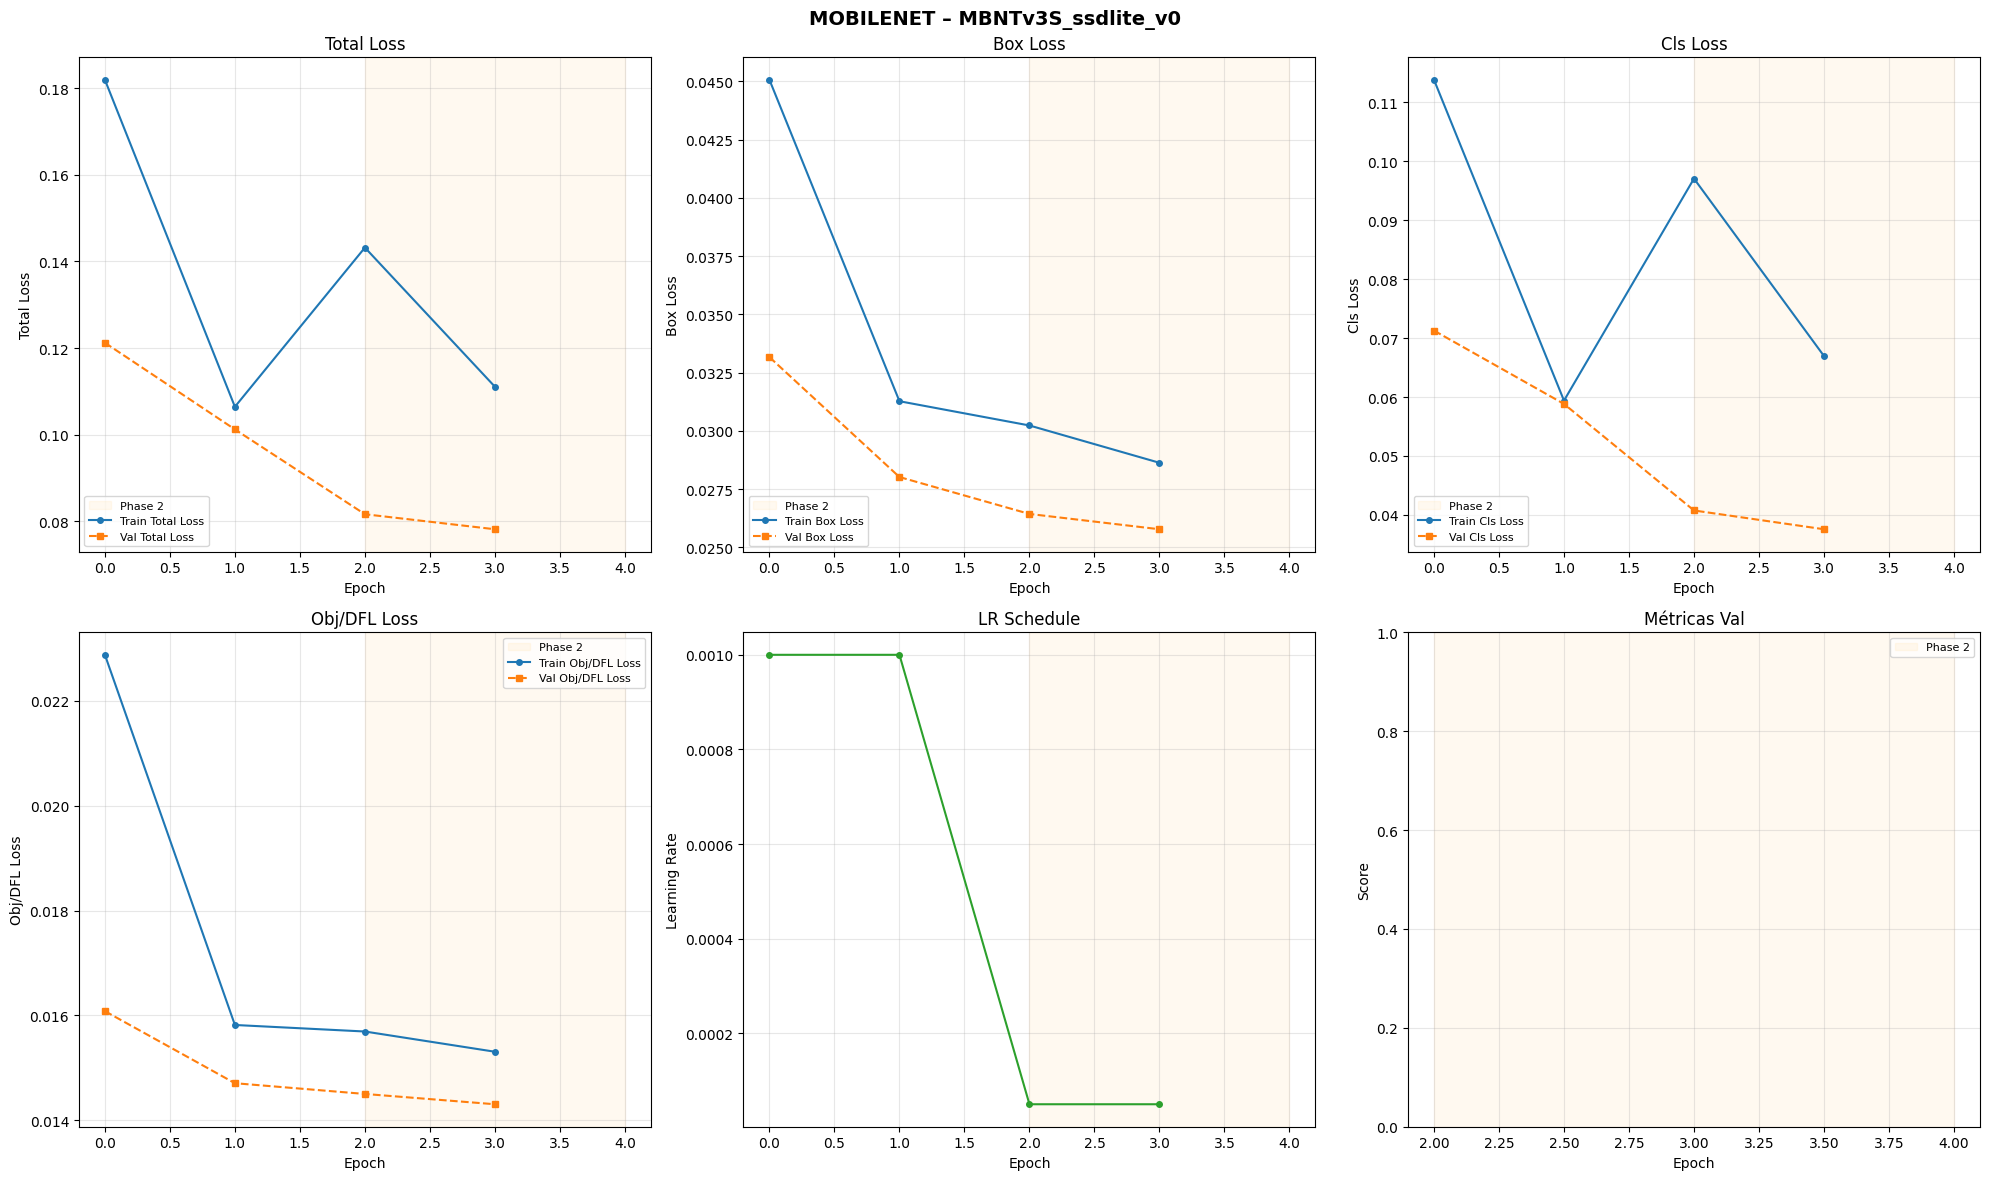


📈 Resumen – MOBILENET MBNTv3S_ssdlite_v0
  Épocas: 4
  Mejor val_loss: 0.0781 (epoch 3)


In [8]:
# ============================================================
# Bloque 6 — Curvas de Entrenamiento
# ============================================================

from src_colab import (
    extract_yolo_history, extract_mobilenet_history,
    plot_training_curves, print_training_summary,
)

if is_yolo_family(family):
    results_csv = os.path.join(exp_dir, "train", "results.csv")
    history = extract_yolo_history(results_csv)
else:
    history = extract_mobilenet_history(combined_csv)

history.model_name = setup.experiment_name

# Guardar figura
curves_path = os.path.join(exp_dir, "training_curves.png")
plot_training_curves(history, save_path=curves_path)
print_training_summary(history)

---
## Bloque 7 — Validación (split=val)

Métricas estandarizadas sobre el conjunto de validación: mAP@50, P, R, F1, confusion matrix.


📊 Evaluación: MBNTv3S_ssdlite_v0 (mobilenet) – split=val
  mAP@50:    0.0108
  mAP@50-95: 0.0000
  Precision: 0.1000
  Recall:    0.0099
  F1-Score:  0.0180
  Imágenes: 2066  |  Detecciones: 18387  |  GT: 197088
  Avg inference: 6.9 ms

  Per-class AP@50:
    dog                   0.0115
    door                  0.0121
    obstacle              0.0099
    person                0.0107
    stair                 0.0099
📊 Confusion matrix guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/val_confusion_matrix.png


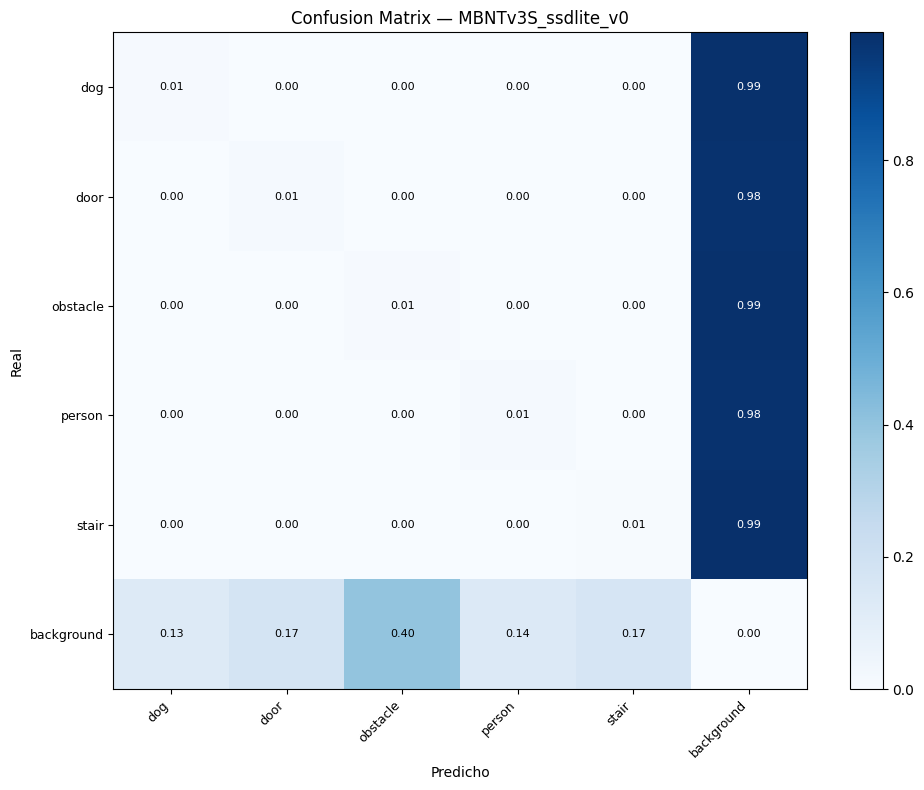

📊 Per-class metrics guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/val_per_class.png


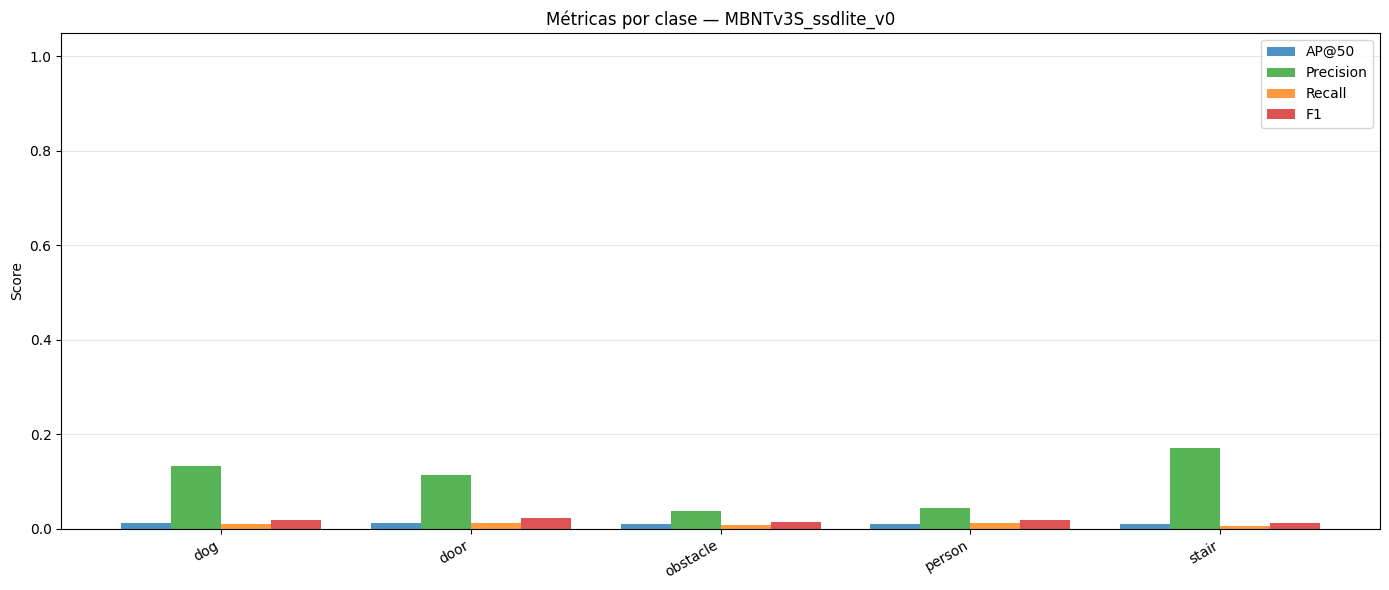

💾 Evaluación guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/val_evaluation.json


In [9]:
# ============================================================
# Bloque 7 — Validación (val)
# ============================================================

from src_colab import (
    evaluate_yolo_model, evaluate_mobilenet_model,
    plot_confusion_matrix, plot_per_class_metrics,
    save_evaluation, validate_mobilenet,
)

if is_yolo_family(family):
    best_pt = os.path.join(exp_dir, "train", "weights", "best.pt")
    val_ev = evaluate_yolo_model(
        model_path=best_pt,
        data_yaml=data_yaml_path,
        split="val",
        imgsz=setup.img_size,
        class_names=setup.class_names,
    )
else:
    val_ev = evaluate_mobilenet_model(
        model=model,
        val_ds=val_ds,
        class_names=setup.class_names,
        imgsz=setup.img_size,
        anchors=anchors,
        model_name=setup.experiment_name,
    )

# Plots
plot_confusion_matrix(val_ev, save_path=os.path.join(exp_dir, "val_confusion_matrix.png"))
plot_per_class_metrics(val_ev, save_path=os.path.join(exp_dir, "val_per_class.png"))
save_evaluation(val_ev, os.path.join(exp_dir, "val_evaluation.json"))

---
## Bloque 8 — Inferencia Visual

Predicciones sobre muestras seleccionadas del dataset para inspección cualitativa.

📊 Visualización guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/inference_samples.png


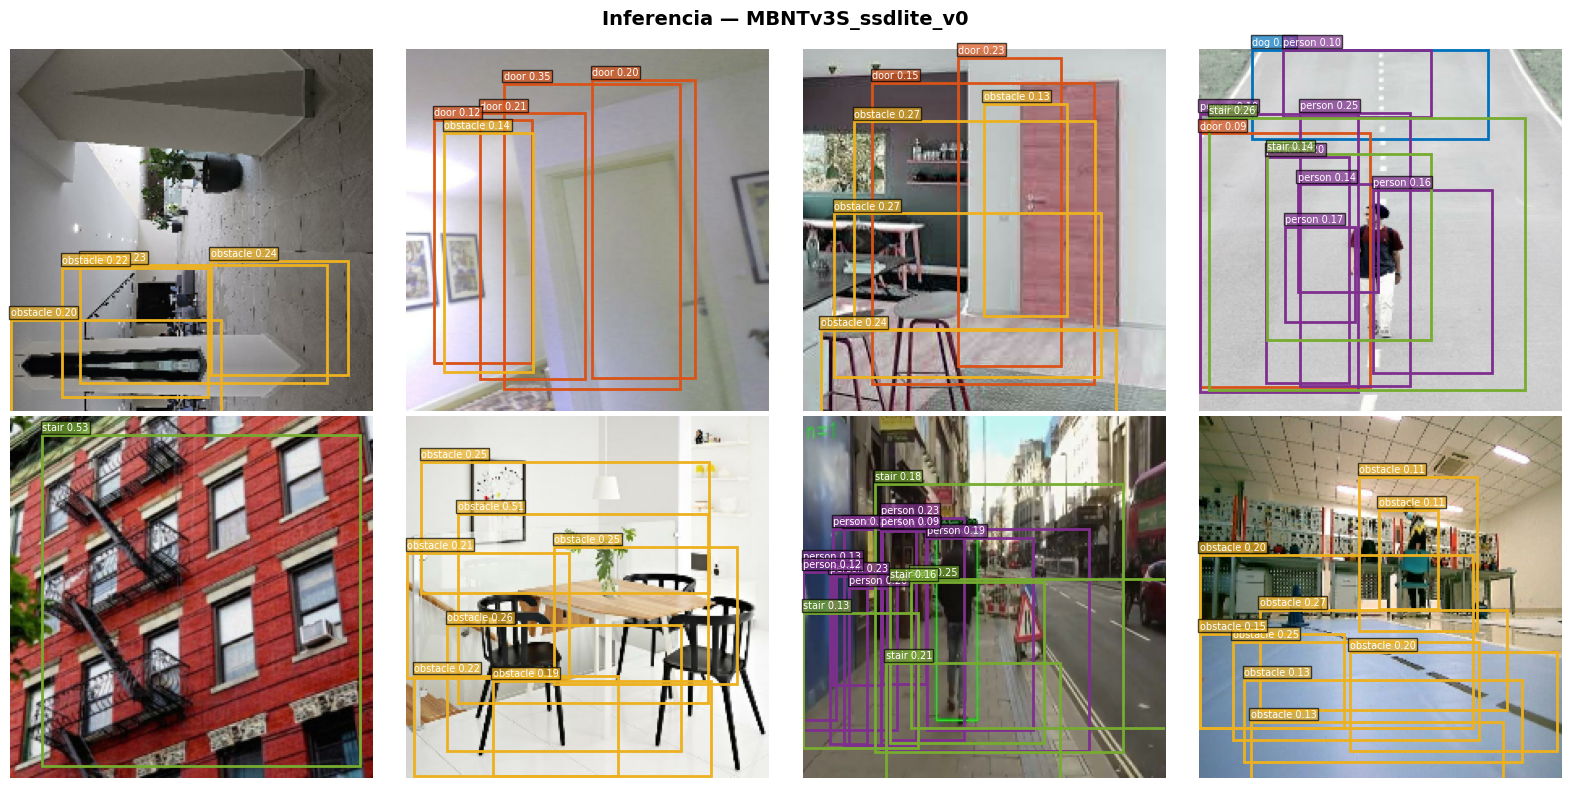

In [ ]:
# ============================================================
# Bloque 8 — Inferencia Visual
# ============================================================

import glob
from src_colab import (
    predict_yolo, predict_mobilenet, visualize_predictions,
)

# Obtener imágenes de val
if is_yolo_family(family):
    # Buscar directorio de validación (valid/ o val/)
    for val_name in ["valid", "val"]:
        val_images_dir = os.path.join(dataset_path, val_name, "images")
        if os.path.isdir(val_images_dir):
            break
    else:
        # Fallback: images/val (formato alternativo)
        val_images_dir = os.path.join(dataset_path, "images", "val")

    sample_paths = sorted(glob.glob(os.path.join(val_images_dir, "*.jpg")))[:20]

    if not sample_paths:
        sample_paths = sorted(glob.glob(os.path.join(val_images_dir, "*.png")))[:20]

    if not sample_paths:
        raise FileNotFoundError(
            f"No se encontraron imágenes en: {val_images_dir}\n"
            f"Contenido de dataset_path: {os.listdir(dataset_path)}"
        )

    vis_paths = sample_paths[:8]
    dets = predict_yolo(
        model_path=best_pt,
        image_paths=vis_paths,
        imgsz=setup.img_size,
        class_names=setup.class_names,
    )
    visualize_predictions(
        vis_paths, dets,
        max_images=8, cols=4,
        save_path=os.path.join(exp_dir, "inference_samples.png"),
        title=f"Inferencia — {setup.experiment_name}",
    )

else:
    import matplotlib.pyplot as plt
    import numpy as np

    # Tomar un batch del val_ds
    sample_batch = next(iter(val_ds))
    sample_imgs = sample_batch[0].numpy()[:8]

    dets = predict_mobilenet(
        model=model, images=sample_imgs,
        class_names=setup.class_names,
        anchors=anchors,
    )
    visualize_predictions(
        [sample_imgs[i] for i in range(len(sample_imgs))],
        dets,
        max_images=8, cols=4,
        save_path=os.path.join(exp_dir, "inference_samples.png"),
        title=f"Inferencia — {setup.experiment_name}",
    )

---
## Bloque 9 — Evaluación Final (split=test)

Métricas definitivas sobre el conjunto de **test**, que NO se ha usado durante el entrenamiento.

📂 Pipeline test: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord/test.tfrecord

📊 Evaluación: MBNTv3S_ssdlite_v0 (mobilenet) – split=val
  mAP@50:    0.0109
  mAP@50-95: 0.0000
  Precision: 0.1011
  Recall:    0.0102
  F1-Score:  0.0185
  Imágenes: 2066  |  Detecciones: 18230  |  GT: 195412
  Avg inference: 5.9 ms

  Per-class AP@50:
    dog                   0.0118
    door                  0.0122
    obstacle              0.0099
    person                0.0109
    stair                 0.0099
📊 Confusion matrix guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/test_confusion_matrix.png


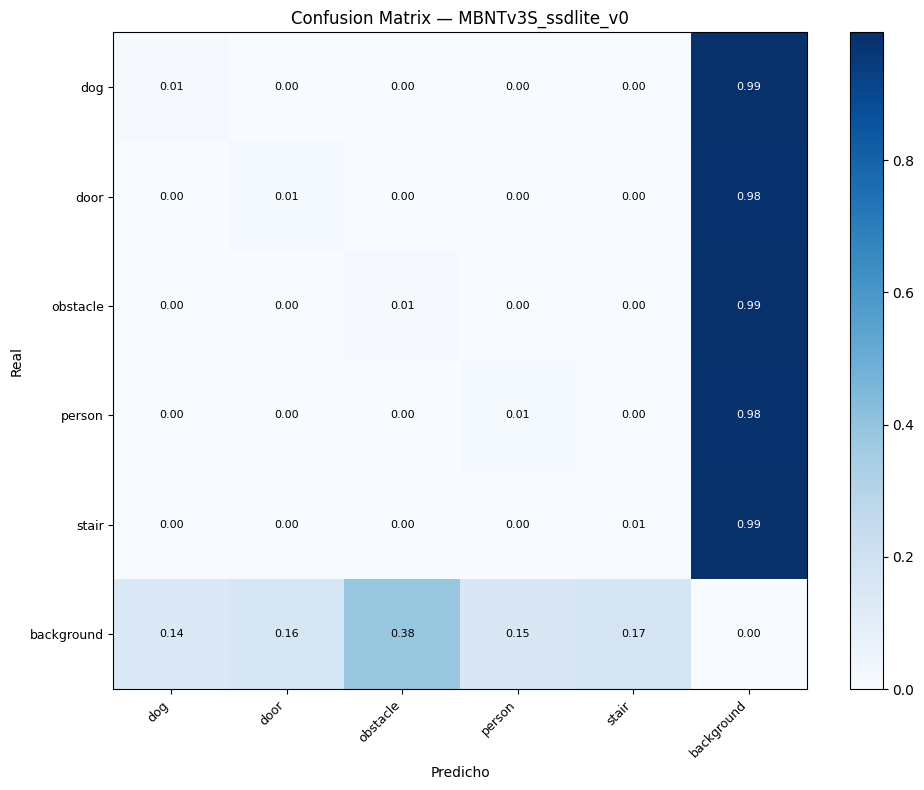

📊 Per-class metrics guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/test_per_class.png


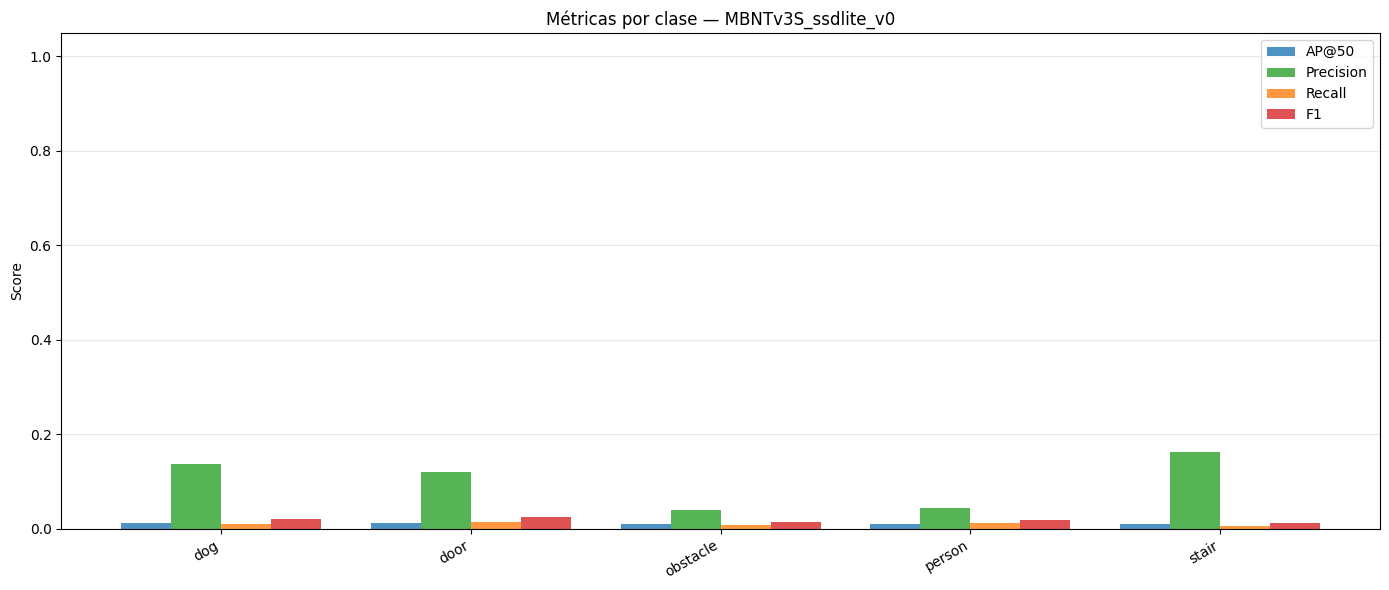

💾 Evaluación guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/test_evaluation.json

📊 TEST: mAP@50=0.0109  P=0.1011  R=0.0102  F1=0.0185


In [11]:
# ============================================================
# Bloque 9 — Evaluación Final (test)
# ============================================================

if is_yolo_family(family):
    test_ev = evaluate_yolo_model(
        model_path=best_pt,
        data_yaml=data_yaml_path,
        split="test",
        imgsz=setup.img_size,
        class_names=setup.class_names,
    )
else:
    test_ds = create_mobilenet_pipeline(
        dataset_path, "test", anchors, setup.class_names,
        batch_size=setup.batch_size, imgsz=setup.img_size,
        augment_level="none",
    )
    test_ev = evaluate_mobilenet_model(
        model=model,
        val_ds=test_ds,
        class_names=setup.class_names,
        imgsz=setup.img_size,
        anchors=anchors,
        model_name=setup.experiment_name,
    )

test_ev.split = "test"
plot_confusion_matrix(test_ev, save_path=os.path.join(exp_dir, "test_confusion_matrix.png"))
plot_per_class_metrics(test_ev, save_path=os.path.join(exp_dir, "test_per_class.png"))
save_evaluation(test_ev, os.path.join(exp_dir, "test_evaluation.json"))

print(f"\n📊 TEST: mAP@50={test_ev.mAP50:.4f}  P={test_ev.precision:.4f}  "
      f"R={test_ev.recall:.4f}  F1={test_ev.f1:.4f}")

---
## Bloque 10 — Export TFLite INT8

Cuantización a INT8 para despliegue en ESP32-S3 (< 8 MB).
- **YOLO**: Ultralytics `model.export(format="tflite", int8=True)`
- **MobileNet**: SavedModel → TFLiteConverter con dataset representativo

In [12]:
# ============================================================
# Bloque 10 — Export TFLite INT8
# ============================================================

from src_colab import (
    export_tflite_int8, create_representative_dataset,
    print_export_report, save_export_result,
)

export_dir = os.path.join(exp_dir, "tflite")

if is_yolo_family(family):
    export_result = export_tflite_int8(
        model=best_pt,
        family=family,
        output_dir=export_dir,
        model_name=setup.experiment_name,
        imgsz=setup.img_size,
        data_yaml=data_yaml_path,
    )
else:
    # Dataset representativo para calibración INT8
    rep_ds = create_representative_dataset(val_ds, n_samples=100, imgsz=setup.img_size)

    export_result = export_tflite_int8(
        model=model,
        family=family,
        output_dir=export_dir,
        model_name=setup.experiment_name,
        imgsz=setup.img_size,
        representative_dataset=rep_ds,
    )

print_export_report(export_result)
save_export_result(export_result, os.path.join(exp_dir, "export_result.json"))

📊 Dataset representativo: 100 muestras

📦 Exportando MobileNet → TFLite INT8
  1/3 Guardando SavedModel...
INFO:tensorflow:Assets written to: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8_saved_model/assets


INFO:tensorflow:Assets written to: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8_saved_model/assets


Saved artifact at '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['objectness', TensorSpec(shape=(None, 1470, 1), dtype=tf.float32, name=None)], ['class_out', TensorSpec(shape=(None, 1470, 5), dtype=tf.float32, name=None)], ['bbox_out', TensorSpec(shape=(None, 1470, 4), dtype=tf.float32, name=None)]]
Captures:
  13206304576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13178721328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13178732064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13178731536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13178730480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13210839248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13210842064: TensorSpec(shape=(), 

W0000 00:00:1770502718.663423  121945 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770502718.663760  121945 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-02-07 17:18:38.665224: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8_saved_model
2026-02-07 17:18:38.670659: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-07 17:18:38.670674: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8_saved_model
I0000 00:00:1770502718.728296  121945 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-02-07 17:18:38.741998: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-07 17:18:39.113021: 

  3/3 Guardando /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8.tflite...

📦 Export: MBNTv3S_ssdlite_v0 (mobilenet)
  Archivo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8.tflite
  Tamaño: 0.75 MB  ✅ ESP32-S3 (<8 MB)
  Input:  (1, 224, 224, 3)
  Quant:  int8
  Tiempo: 8.5s
  Outputs:
    StatefulPartitionedCall_1:2: (1, 1470, 1)
    StatefulPartitionedCall_1:1: (1, 1470, 5)
    StatefulPartitionedCall_1:0: (1, 1470, 4)

📦 Export: MBNTv3S_ssdlite_v0 (mobilenet)
  Archivo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8.tflite
  Tamaño: 0.75 MB  ✅ ESP32-S3 (<8 MB)
  Input:  (1, 224, 224, 3)
  Quant:  int8
  Tiempo: 8.5s
  Outputs:
    StatefulPartitionedCall_1:2: (1, 1470, 1)
    StatefulPartitionedCall_1:1: (1, 1470, 5)
    StatefulPartitionedCall_1:0: (1, 1470, 4)
💾 Export result guardado: /Users/admin/Documents/TFM_U

fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: FLOAT32
/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


---
## Bloque 11 — Comparación Framework vs TFLite

Verificar que el modelo cuantizado produce resultados consistentes
con el modelo original: agreement rate, distribución de IoU, scatter plot.


🔄 Comparando framework vs TFLite (MobileNetV3)
   TFLite: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/tflite/MBNTv3S_ssdlite_v0_int8.tflite
   Muestras: 12


/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



❌ Verificación TFLite (12 muestras)
  Agreement: 54.7%
  Avg IoU: 0.6320
  Avg Δconf: 0.0658
  Avg latency: 0.7 ms
💾 Comparison result: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/comparison_result.json
🔍  Evaluación TFLite sobre test split (mAP, P, R, F1)

📊 Evaluación: MBNTv3S_ssdlite_v0_tflite (tflite) – split=test
  mAP@50:    0.0090
  mAP@50-95: 0.0000
  Precision: 0.0875
  Recall:    0.0078
  F1-Score:  0.0143
  Imágenes: 2066  |  Detecciones: 15387  |  GT: 195412
  Avg inference: 0.7 ms

  Per-class AP@50:
    dog                   0.0113
    door                  0.0059
    obstacle              0.0099
    person                0.0079
    stair                 0.0099
📊 FW vs TFLite metrics guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/fw_vs_tflite_metrics.png


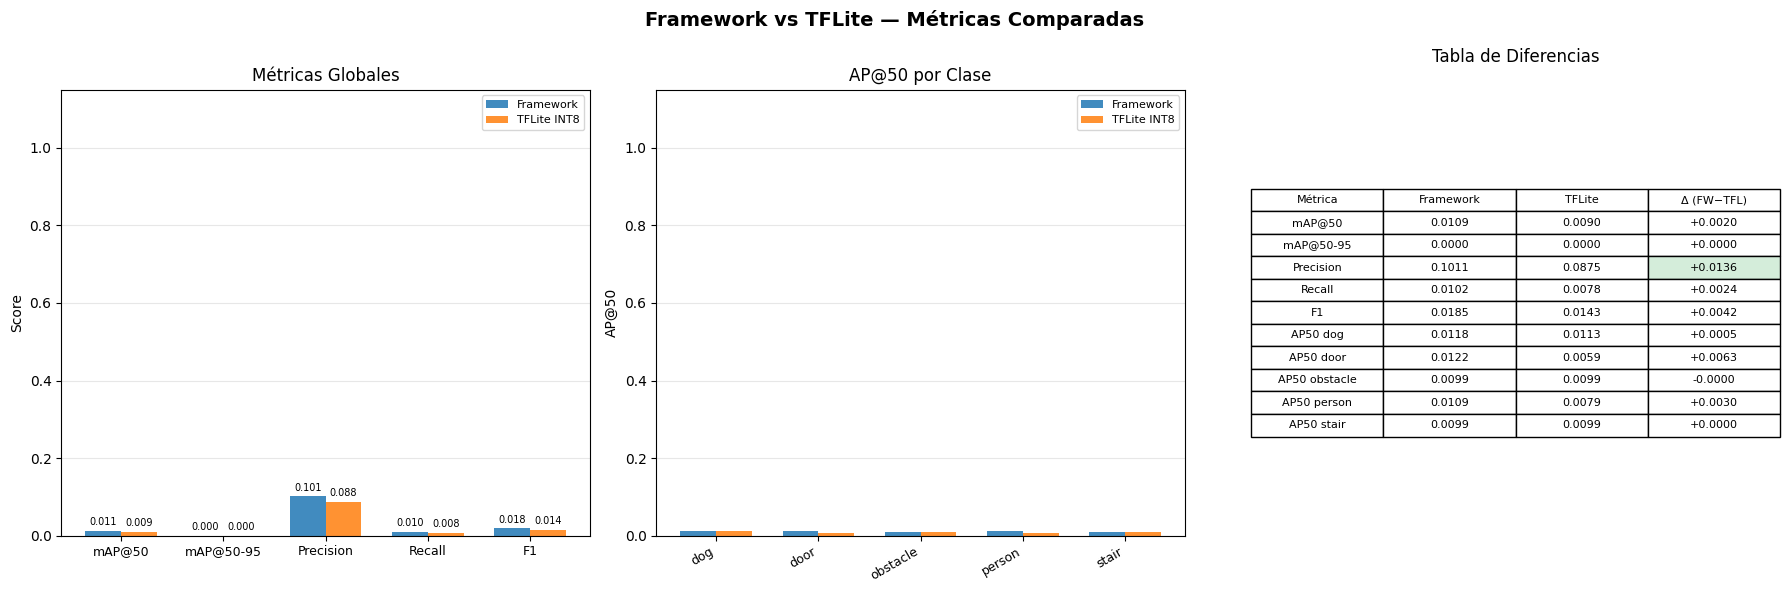

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


📊 FW vs TFLite samples guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/fw_vs_tflite_samples.png


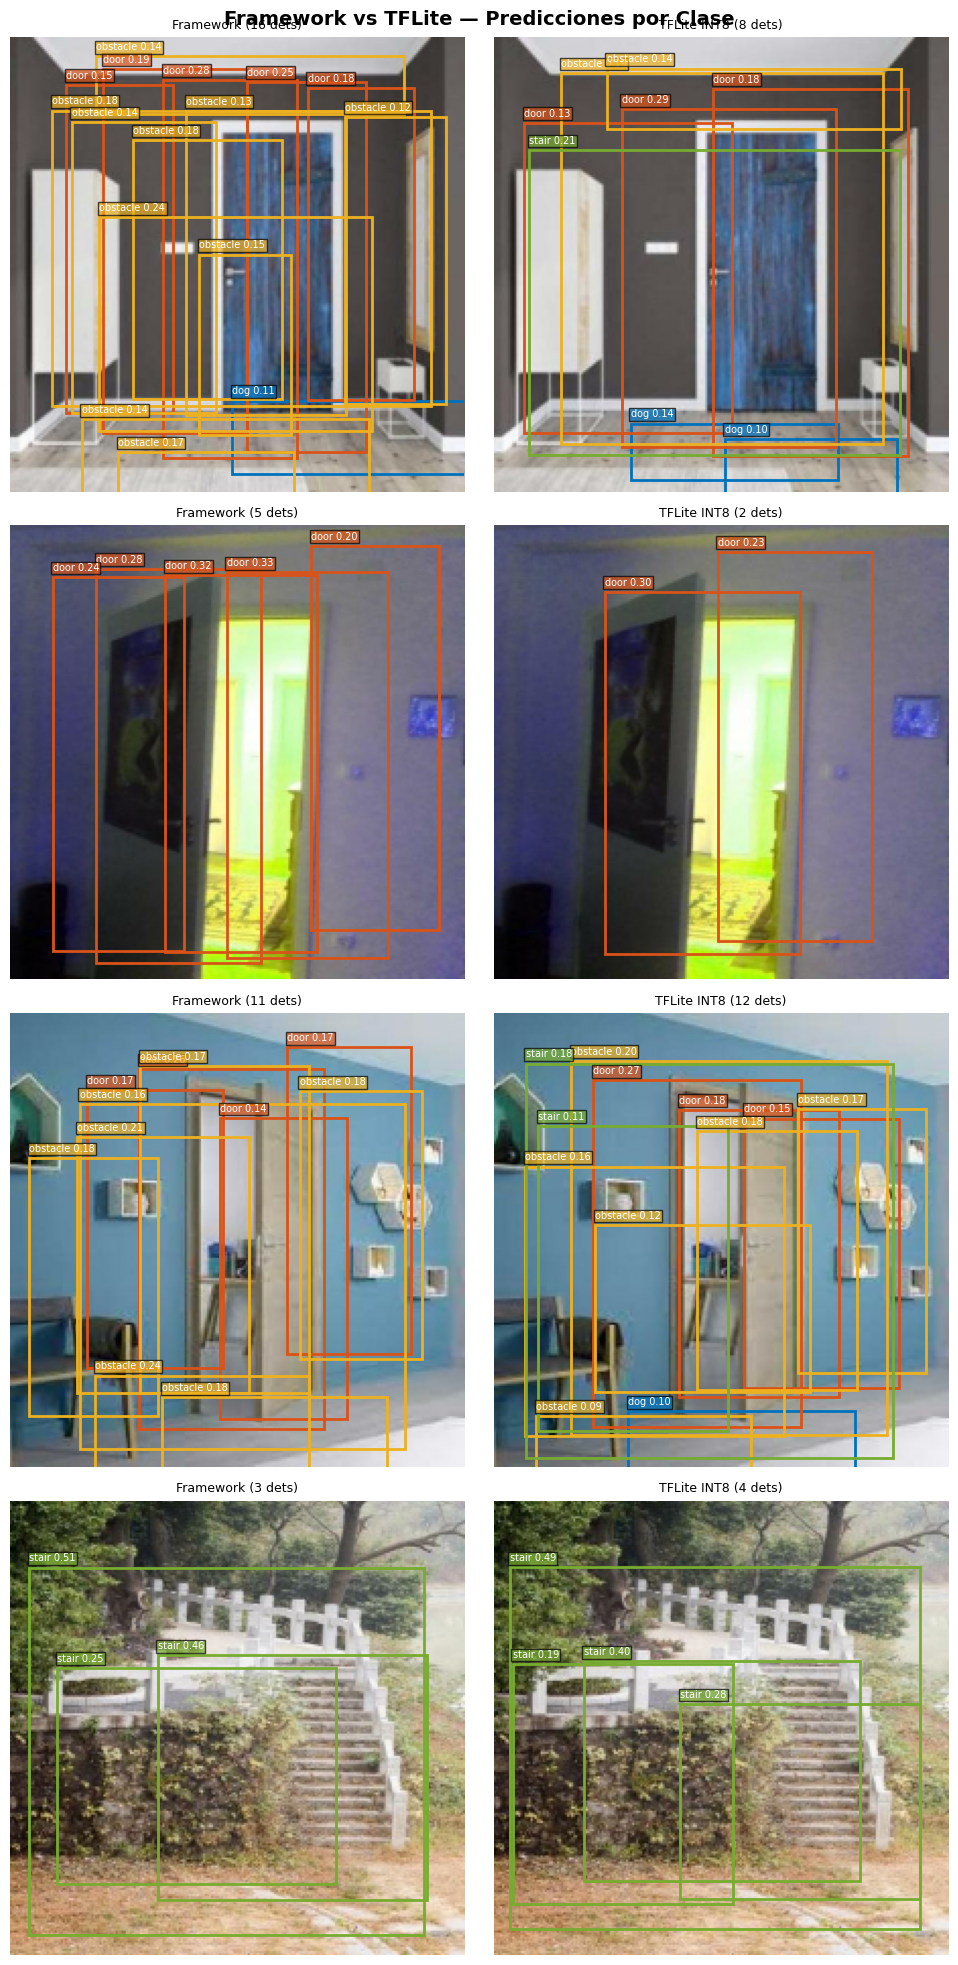

In [17]:
# ============================================================
# Bloque 11 — Comparación Framework vs TFLite
# ============================================================

import numpy as np
from src_colab import (
    compare_framework_vs_tflite, save_comparison_result,
    evaluate_tflite_model,
    plot_fw_vs_tflite_metrics, visualize_fw_vs_tflite_samples,
    predict_mobilenet, predict_tflite, predict_yolo,
)

# ── 11.1  Comparación rápida (agreement, IoU, Δconf) — existente ──
N_COMPARE = 20

if is_yolo_family(family):
    import cv2
    compare_paths = sample_paths[:N_COMPARE]
    compare_imgs = []
    for p in compare_paths:
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (setup.img_size, setup.img_size))
        compare_imgs.append(img / 255.0)
    compare_imgs = np.array(compare_imgs, dtype=np.float32)

    comparison = compare_framework_vs_tflite(
        framework_model=best_pt,
        tflite_path=export_result.tflite_path,
        images=compare_imgs,
        class_names=setup.class_names,
        family=family,
        model_path=best_pt,
        imgsz=setup.img_size,
    )
else:
    compare_batch = next(iter(val_ds))
    compare_imgs = compare_batch[0].numpy()[:N_COMPARE]

    comparison = compare_framework_vs_tflite(
        framework_model=model,
        tflite_path=export_result.tflite_path,
        images=compare_imgs,
        class_names=setup.class_names,
        family=family,
        anchors=anchors,
        imgsz=setup.img_size,
    )

save_comparison_result(comparison, os.path.join(exp_dir, "comparison_result.json"))


# ── 11.2  Evaluación completa TFLite sobre test split ──

print("🔍  Evaluación TFLite sobre test split (mAP, P, R, F1)")


if is_yolo_family(family):
    tflite_test_ev = evaluate_tflite_model(
        tflite_path=export_result.tflite_path,
        class_names=setup.class_names,
        imgsz=setup.img_size,
        conf_threshold=0.25,
        iou_threshold=0.5,
        model_name=f"{setup.experiment_name}_tflite",
        dataset_dir=dataset_path,
        split="test",
    )
else:
    tflite_test_ev = evaluate_tflite_model(
        tflite_path=export_result.tflite_path,
        class_names=setup.class_names,
        imgsz=setup.img_size,
        conf_threshold=0.25,
        iou_threshold=0.5,
        model_name=f"{setup.experiment_name}_tflite",
        test_ds=test_ds,
    )


# ── 11.3  Gráfica comparativa: Framework (test_ev) vs TFLite (tflite_test_ev) ──
plot_fw_vs_tflite_metrics(
    fw_ev=test_ev,
    tfl_ev=tflite_test_ev,
    save_path=os.path.join(exp_dir, "fw_vs_tflite_metrics.png"),
)


# ── 11.4  Visualización side-by-side: 1 imagen por clase ──
if is_yolo_family(family):
    fw_vis_dets = predict_yolo(
        model_path=best_pt,
        image_paths=[compare_imgs[i] for i in range(compare_imgs.shape[0])],
        imgsz=setup.img_size, conf=0.25, iou=0.45,
        class_names=setup.class_names,
    )
else:
    fw_vis_dets = predict_mobilenet(
        model=model, images=compare_imgs,
        class_names=setup.class_names,
        anchors=anchors,
    )

tfl_vis_dets, _ = predict_tflite(
    tflite_path=export_result.tflite_path,
    images=compare_imgs,
    class_names=setup.class_names,
    conf_threshold=0.25,
    iou_threshold=0.45,
)

visualize_fw_vs_tflite_samples(
    images=[compare_imgs[i] for i in range(compare_imgs.shape[0])],
    fw_dets=fw_vis_dets,
    tfl_dets=tfl_vis_dets,
    class_names=setup.class_names,
    samples_per_class=1,
    save_path=os.path.join(exp_dir, "fw_vs_tflite_samples.png"),
)

---
## Bloque 12 — Registro y Comparación de Experimentos

Guardar el experimento completo como JSON unificado y comparar con
todos los experimentos previos almacenados en Drive.

💾 Experimento guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/MBNTv3S_ssdlite_v0/experiment.json
📂 Cargados 3 experimentos de /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models

              name      family              variant  val_mAP50   val_f1  tflite_mb  tflite_ok  train_time_min
      yolo11n_v0-2      YOLO11              yolo11n   0.000000 0.000000   2.678461       True        1.580142
 MBNTv2_ssdlite_v0 MobileNetV2  MobileNetV2_SSDLite   0.009233 0.015968   2.859550       True        9.200000
MBNTv3S_ssdlite_v0 MobileNetV3 MobileNetV3S_SSDLite   0.010829 0.018041   0.750397       True        5.189440


/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/Google_Colab/src_colab/utils_experiment.py:358: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  import pandas as pd


📊 Comparativa guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/experiments_comparison.png


/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


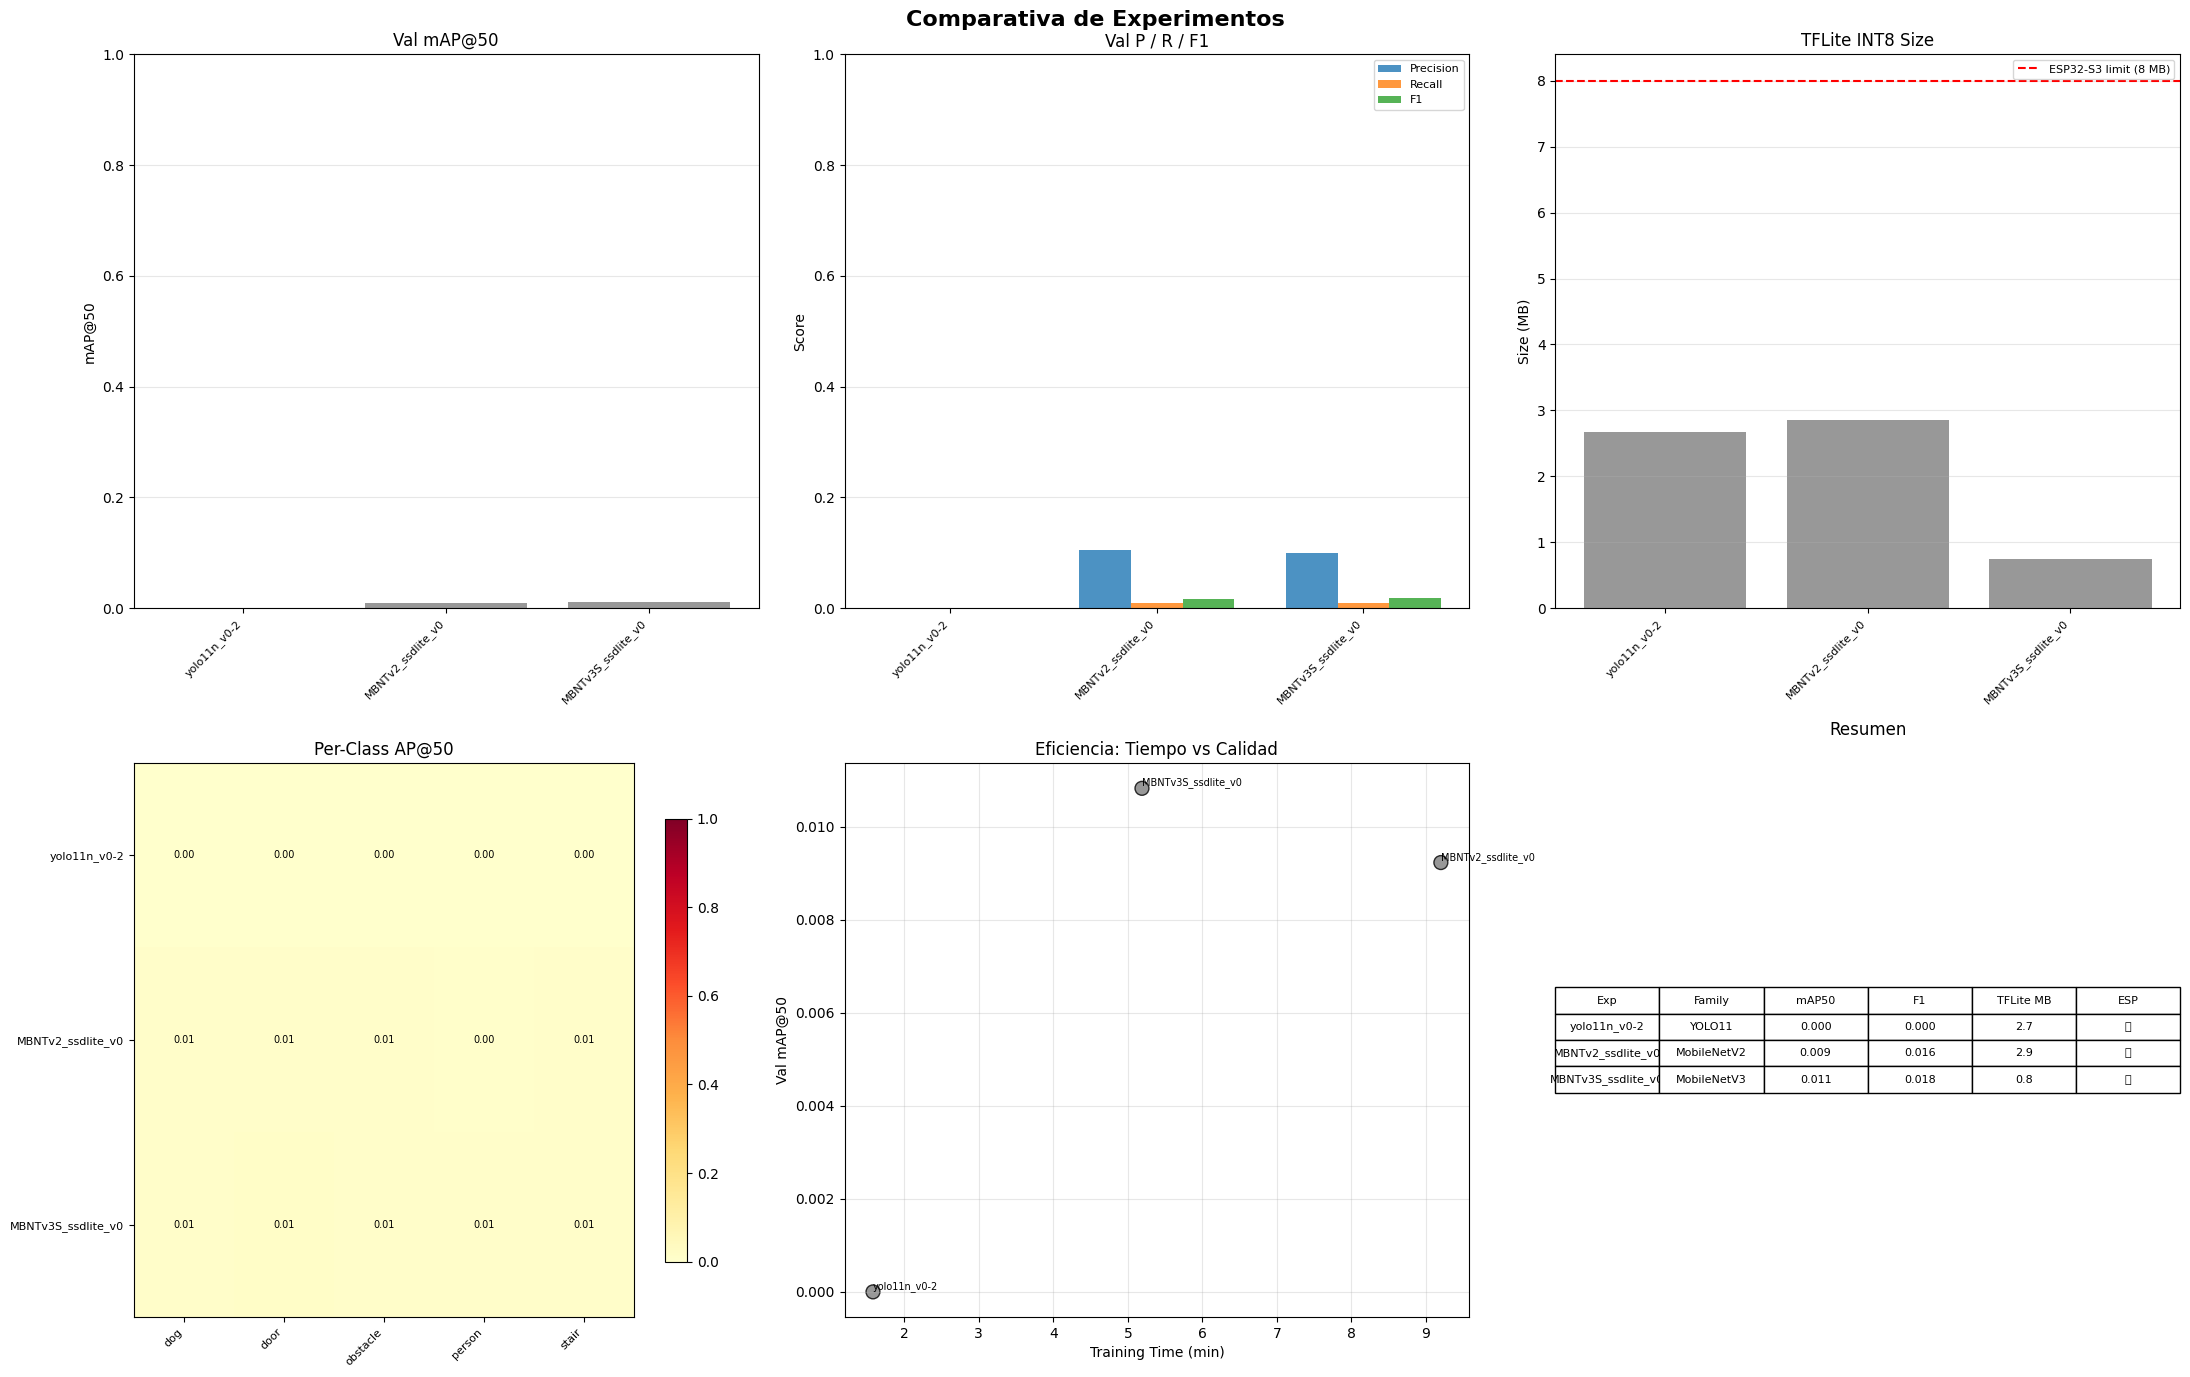

💾 CSV comparativo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/experiments_comparison.csv


In [18]:
# ============================================================
# Bloque 12 — Registro y Comparación
# ============================================================

from src_colab import (
    UnifiedExperiment, create_experiment_from_setup,
    save_experiment, load_all_experiments,
    plot_experiments_comparison, print_experiments_table,
    save_comparison_csv,
)

# 12.1  Crear y rellenar experimento unificado
experiment = create_experiment_from_setup(setup)
r = experiment.results

# Training metrics
r.training_time_min = training_time_min
r.total_epochs_run = history.n_epochs
if history.val_total_loss:
    r.best_val_loss = min(history.val_total_loss)
    r.best_epoch = history.best_epoch_by_val_loss
    r.final_val_loss = history.val_total_loss[-1]
if history.train_total_loss:
    r.final_train_loss = history.train_total_loss[-1]

# Val metrics (Framework)
r.val_mAP50 = val_ev.mAP50
r.val_mAP50_95 = val_ev.mAP50_95
r.val_precision = val_ev.precision
r.val_recall = val_ev.recall
r.val_f1 = val_ev.f1
r.val_per_class_ap50 = val_ev.per_class_ap50

# Test metrics (Framework)
r.test_mAP50 = test_ev.mAP50
r.test_mAP50_95 = test_ev.mAP50_95
r.test_precision = test_ev.precision
r.test_recall = test_ev.recall
r.test_f1 = test_ev.f1
r.test_per_class_ap50 = test_ev.per_class_ap50

# Export metrics
r.tflite_size_mb = export_result.size_mb
r.tflite_esp32_ok = export_result.esp32_compatible
r.tflite_agreement = comparison.agreement_rate
r.tflite_avg_latency_ms = comparison.avg_inference_ms

# TFLite test metrics (from Bloque 11)
r.tflite_test_mAP50 = tflite_test_ev.mAP50
r.tflite_test_mAP50_95 = tflite_test_ev.mAP50_95
r.tflite_test_precision = tflite_test_ev.precision
r.tflite_test_recall = tflite_test_ev.recall
r.tflite_test_f1 = tflite_test_ev.f1
r.tflite_test_per_class_ap50 = tflite_test_ev.per_class_ap50

# 12.2  Guardar
save_experiment(experiment, exp_dir)

# 12.3  Cargar TODOS los experimentos y comparar
all_exps = load_all_experiments(paths.models_dir)

if len(all_exps) > 1:
    print_experiments_table(all_exps)
    plot_experiments_comparison(
        all_exps,
        save_path=os.path.join(paths.reports_dir, "experiments_comparison.png"),
    )
    save_comparison_csv(all_exps, os.path.join(paths.reports_dir, "experiments_comparison.csv"))
else:
    print("ℹ️  Solo hay 1 experimento, comparación disponible tras más entrenamientos.")

---
## ✅ Resumen Final

El experimento ha sido guardado en:
```
{exp_dir}/
├── experiment.json          ← Schema unificado
├── training_curves.png      ← Curvas 6-panel
├── val_evaluation.json      ← Métricas val
├── test_evaluation.json     ← Métricas test
├── export_result.json       ← Resultado TFLite
├── comparison_result.json   ← Framework vs TFLite
├── inference_samples.png    ← Visualización
├── tflite/                  ← Modelo INT8
├── train/                   ← (YOLO) weights, results
├── checkpoints/             ← (MobileNet) .keras
└── logs/                    ← CSVs, TensorBoard
```

Para siguiente experimento: **volver al Bloque 2** y cambiar los parámetros.